# 01: Surveillance EDA

In [1]:
#imports and connection
from google.cloud import bigquery
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mtick 
import seaborn as sns 
import numpy as np 

PROJECT = "ae-project-portfolio"
DATASET = "marts"

client = bigquery.Client(project=PROJECT)

def query(sql):
    return client.query(sql).to_dataframe()

print("Connected!")

Connected!


## Dataset Overview

In [2]:
tables = [
    'fct_weekly_deaths',
    'fct_outbreak_flags',
    'fct_state_mortality',
    'fct_pathogen_trends'
]

rows = []
for table in tables:
    result = query(f"select count(*) as cnt from `{PROJECT}.{DATASET}.{table}`")
    rows.append({'model': table, 'rows': result['cnt'][0]})

print(pd.DataFrame(rows).to_string(index=False))

/opt/miniconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


              model  rows
  fct_weekly_deaths   200
 fct_outbreak_flags   199
fct_state_mortality 32606
fct_pathogen_trends   573


## Weekly Death trends

/opt/miniconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


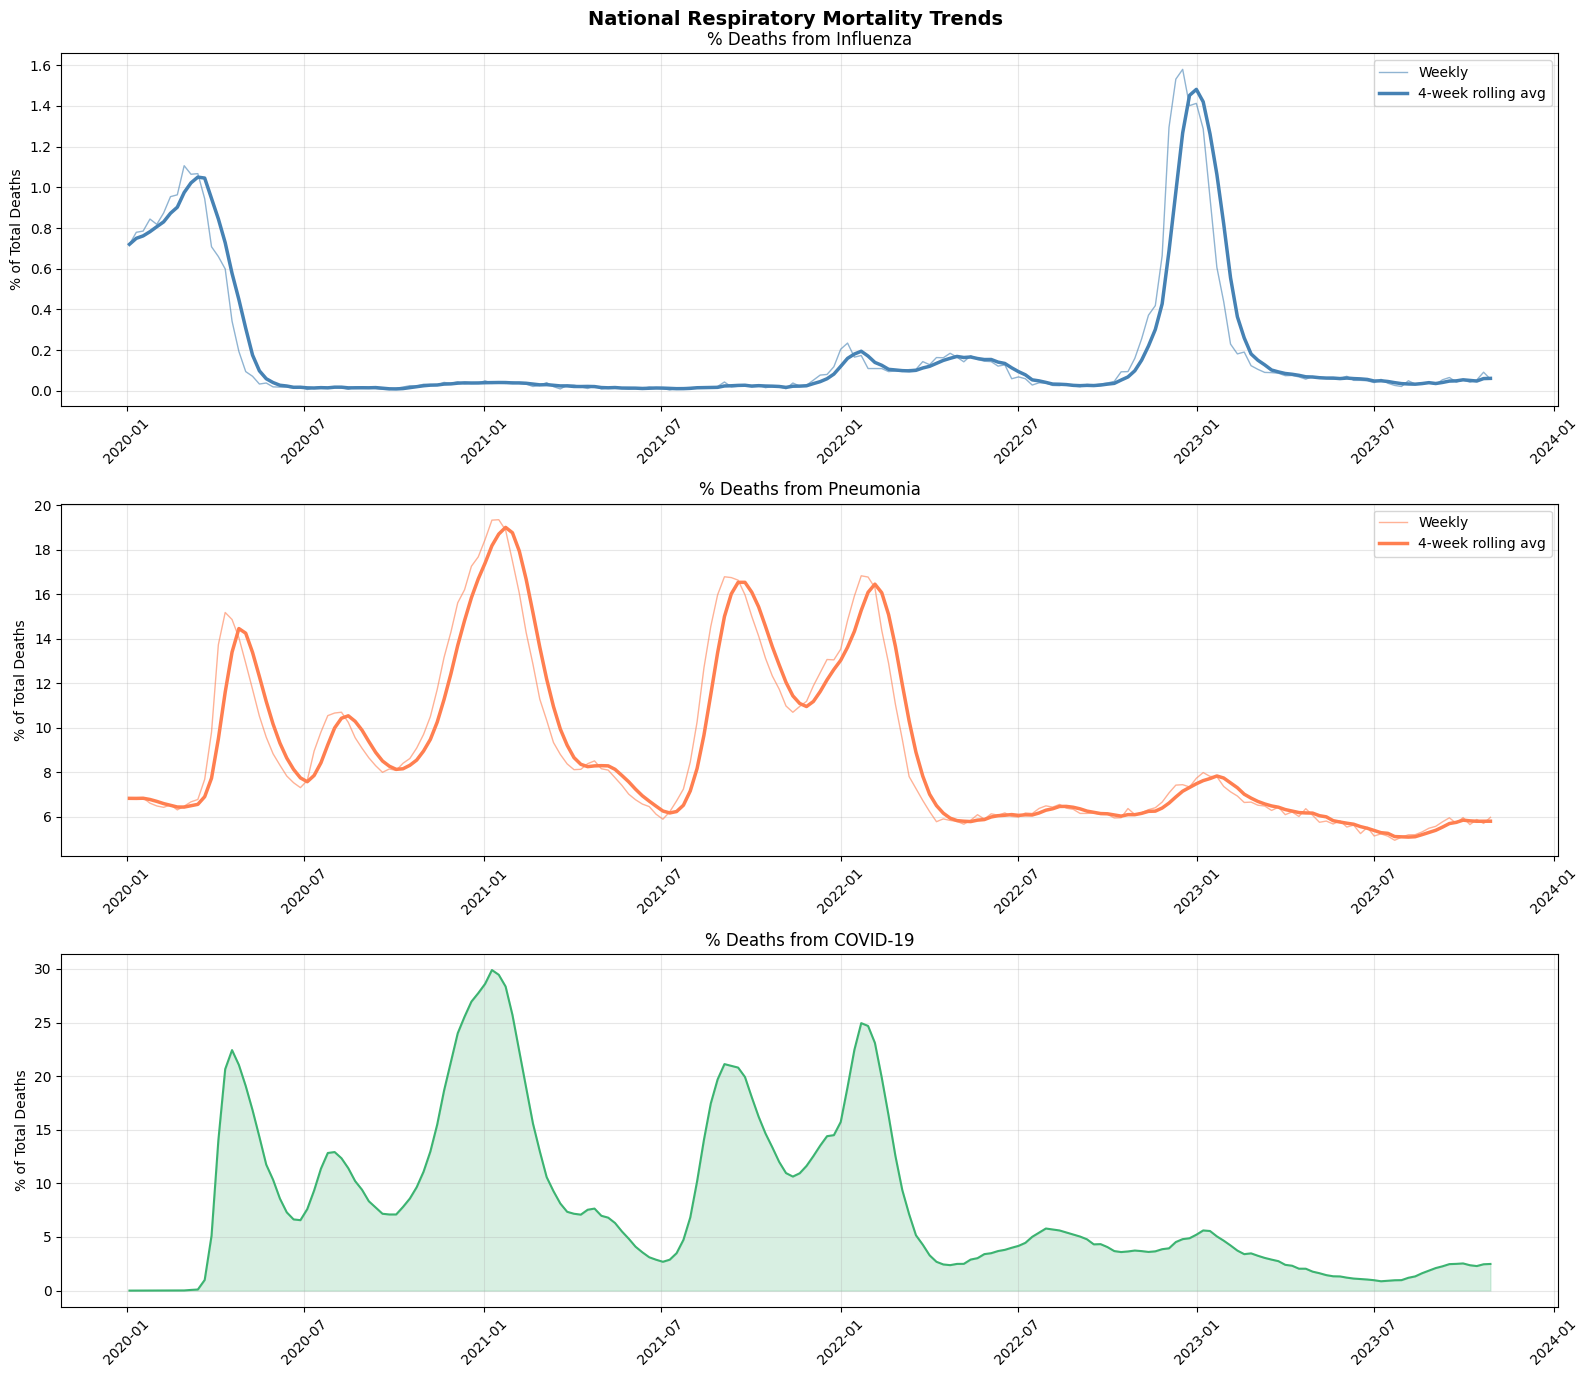

In [3]:
weekly = query(f"""
select
    week_ending_date,
    mmwr_year,
    mmwr_week,
    flu_season_period,
    pct_influenza,
    pct_pneumonia,
    pct_covid,
    rolling_4w_pct_influenza,
    rolling_4w_pct_pneumonia,
    zscore_influenza,
    zscore_pneumonia,
    wow_change_influenza
from `{PROJECT}.{DATASET}.fct_weekly_deaths`
order by week_ending_date
""")

fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('National Respiratory Mortality Trends', fontsize=14, fontweight='bold')

#influenza % over time
axes[0].plot(weekly['week_ending_date'], weekly['pct_influenza'],
            color='steelblue', linewidth=1, alpha=0.6, label='Weekly')
axes[0].plot(weekly['week_ending_date'], weekly['rolling_4w_pct_influenza'],
            color='steelblue', linewidth=2.5, label='4-week rolling avg')
axes[0].set_title('% Deaths from Influenza')
axes[0].set_ylabel('% of Total Deaths')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

#pneumonia % over time
axes[1].plot(weekly['week_ending_date'], weekly['pct_pneumonia'],
            color='coral', linewidth=1, alpha=0.6, label='Weekly')
axes[1].plot(weekly['week_ending_date'], weekly['rolling_4w_pct_pneumonia'],
            color='coral', linewidth=2.5, label='4-week rolling avg')
axes[1].set_title('% Deaths from Pneumonia')
axes[1].set_ylabel('% of Total Deaths')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

#covid % over time
axes[2].plot(weekly['week_ending_date'], weekly['pct_covid'],
            color='mediumseagreen', linewidth=1.5)
axes[2].fill_between(weekly['week_ending_date'], weekly['pct_covid'],
                    alpha=0.2, color='mediumseagreen')
axes[2].set_title('% Deaths from COVID-19')
axes[2].set_ylabel('% of Total Deaths')
axes[2].grid(True, alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('mortality_trends.png', dpi=150, bbox_inches='tight')
plt.show()

### Outbreak detection visualization

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


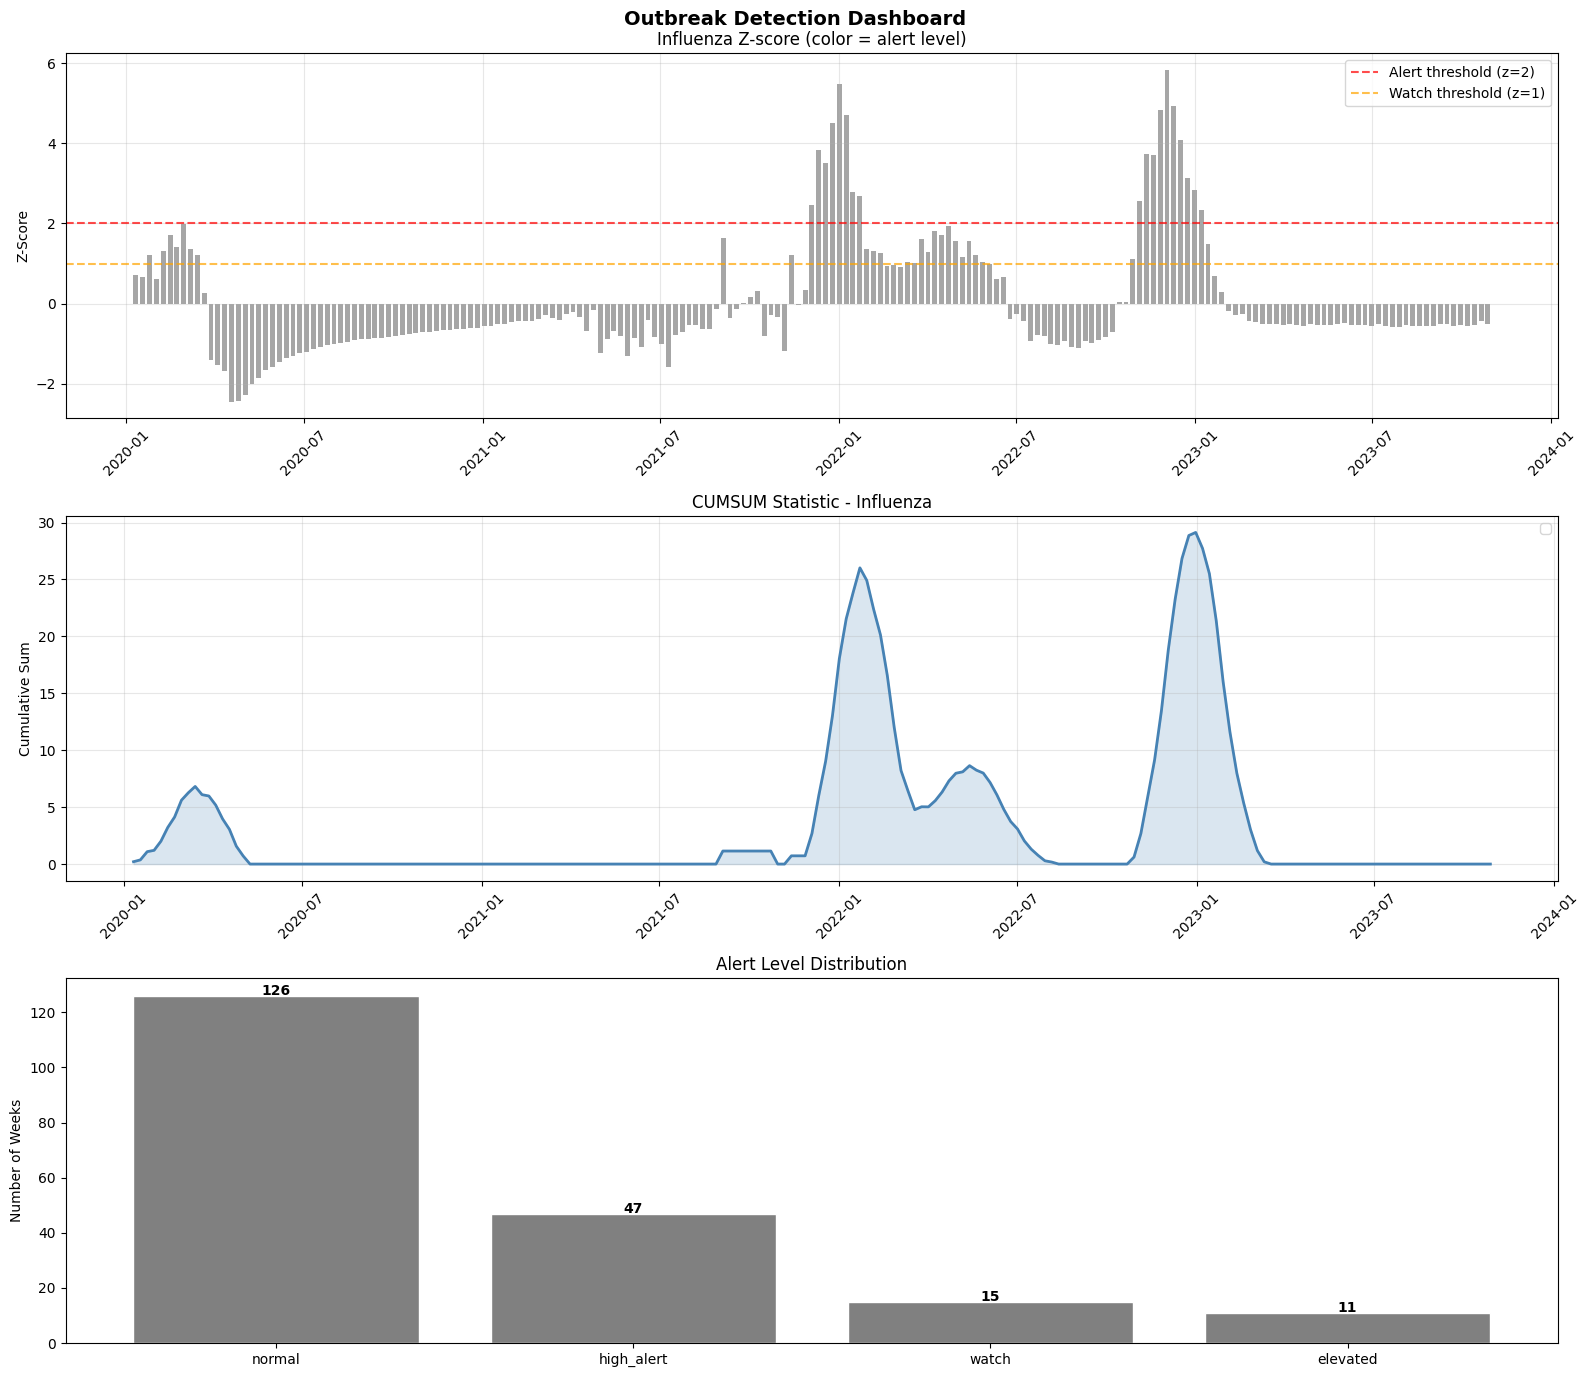


Alert level summary:
alert_level
normal        126
high_alert     47
watch          15
elevated       11


In [4]:
outbreak = query(f"""
select
    week_ending_date,
    alert_level,
    zscore_influenza,
    zscore_pneumonia,
    cumsum_influenza,
    cumsum_pneumonia,
    weeks_eleveated_last_8,
    pct_influenza,
    rolling_4w_pct_influenza
from `{PROJECT}.{DATASET}.fct_outbreak_flags`
order by week_ending_date
""")

#color map for alert levels
alert_colors = {
    'normal': '#4CAF50',
    'watch': '#FF9800',
    'elevated': '#F44336',
    'high_alert': '#9C27BO'
}

fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('Outbreak Detection Dashboard', fontsize=14, fontweight='bold')

#z-score time series with alert shading
colors = [alert_colors.get(1, 'gray') for l in outbreak['alert_level']]
axes[0].bar(outbreak['week_ending_date'], outbreak['zscore_influenza'],
            color=colors, alpha=0.7, width=5)
axes[0].axhline(y=2.0, color='red', linestyle='--',
                alpha=0.7, label='Alert threshold (z=2)')
axes[0].axhline(y=1.0, color='orange', linestyle='--',
                alpha=0.7, label='Watch threshold (z=1)')
axes[0].set_title('Influenza Z-score (color = alert level)')
axes[0].set_ylabel('Z-Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

#CUMSUM stat
axes[1].plot(outbreak['week_ending_date'], outbreak['cumsum_influenza'],
             color='steelblue', linewidth=2)
axes[1].fill_between(outbreak['week_ending_date'], outbreak['cumsum_influenza'],
                     alpha=0.2, color='steelblue')
axes[1].set_title('CUMSUM Statistic - Influenza')
axes[1].set_ylabel('Cumulative Sum')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

#alert level distribution
alert_counts = outbreak['alert_level'].value_counts()
bar_colors = [alert_colors.get(1, 'gray') for l in alert_counts.index]
axes[2].bar(alert_counts.index, alert_counts.values, color=bar_colors,
            edgecolor='white')
axes[2].set_title('Alert Level Distribution')
axes[2].set_ylabel('Number of Weeks')
for i,v in enumerate(alert_counts.values):
    axes[2].text(i,v + 0.3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('outbreak_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAlert level summary:")
print(outbreak['alert_level'].value_counts().to_string())

### Pathogen Comparison

/opt/miniconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


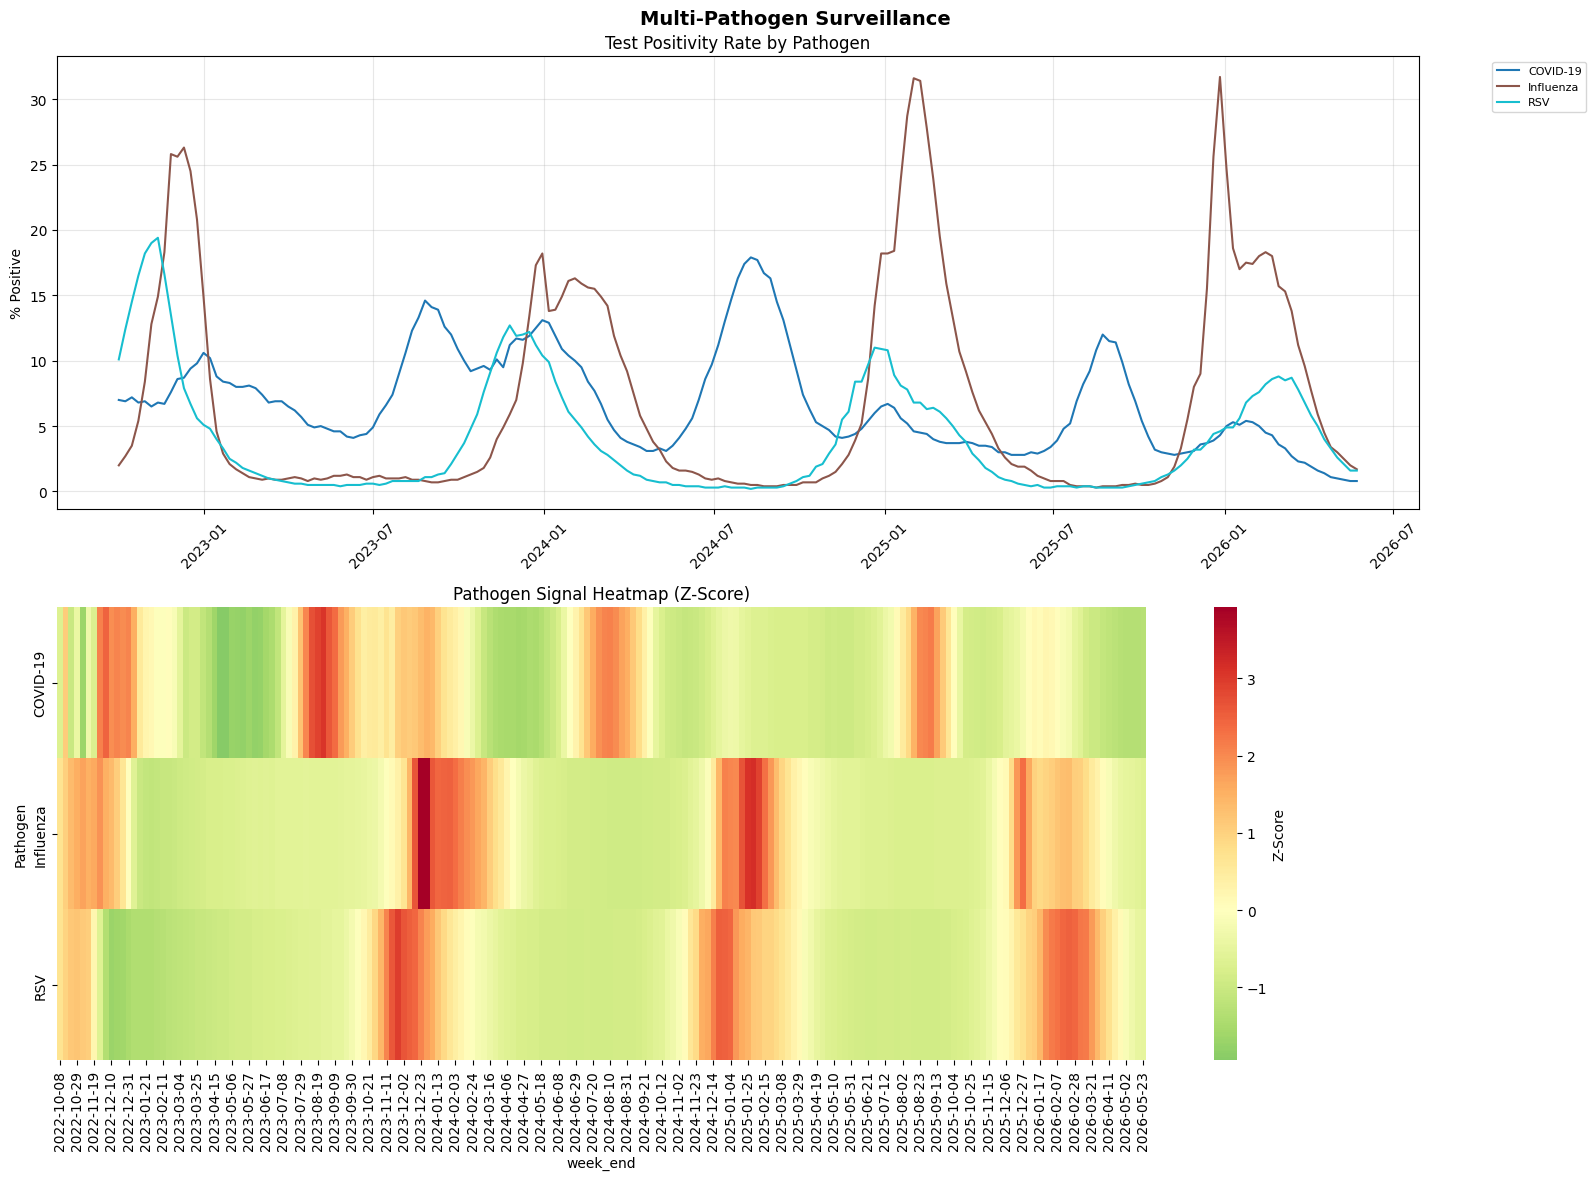

In [5]:
pathogens = query(f"""
select
    week_end,
    pathogen,
    pct_positive,
    rolling_4w_pct_positive,
    zscore,
    signal_level
from `{PROJECT}.{DATASET}.fct_pathogen_trends`
order by week_end, pathogen
""")

pathogen_list = pathogens['pathogen'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(pathogen_list)))

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Multi-Pathogen Surveillance', fontsize=14, fontweight='bold')

for pathogen, color in zip(pathogen_list, colors):
    df = pathogens[pathogens['pathogen'] == pathogen].sort_values('week_end')
    axes[0].plot(df['week_end'], df['pct_positive'],
                label=pathogen, linewidth=1.5, color=color)

axes[0].set_title('Test Positivity Rate by Pathogen')
axes[0].set_ylabel('% Positive')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

#signal level heatmap
pivot = pathogens.pivot_table(
    index='pathogen',
    columns='week_end',
    values='zscore',
    aggfunc='mean'
).fillna(0)

sns.heatmap(pivot, cmap='RdYlGn_r', center=0,
           ax=axes[1], cbar_kws={'label': 'Z-Score'})
axes[1].set_title('Pathogen Signal Heatmap (Z-Score)')
axes[1].set_ylabel('Pathogen')

plt.tight_layout()
plt.savefig('pathogen_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ── Cell 6: State mortality heatmap ───────────────────────────────────────────
state_mort = query(f"""
select
    state,
    season,
    avg(pct_pi)                 as avg_pct_pi,
    sum(pi_deaths)              as total_pi_deaths
from `{PROJECT}.{DATASET}.fct_state_mortality`
where geoid = 'State'
  and age = 'All'
  and state != ''
  and state not in ('Puerto Rico', 'New York City')
group by 1, 2
order by 1, 2
""")

print(f"Rows: {len(state_mort)}")
print(f"avg_pct_pi range: {state_mort['avg_pct_pi'].min():.2f} to {state_mort['avg_pct_pi'].max():.2f}")
print(state_mort.head(10))

Rows: 510
avg_pct_pi range: 0.00 to 0.00
     state   season  avg_pct_pi  total_pi_deaths
0  Alabama  2009-10         0.0           3450.0
1  Alabama  2010-11         0.0           3354.0
2  Alabama  2011-12         0.0           3289.0
3  Alabama  2012-13         0.0           3313.0
4  Alabama  2013-14         0.0           3207.0
5  Alabama  2014-15         0.0           3402.0
6  Alabama  2015-16         0.0           2932.0
7  Alabama  2016-17         0.0           3056.0
8  Alabama  2017-18         0.0           3448.0
9  Alabama  2018-19         0.0           1516.0


/opt/miniconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


### State Mortality heatmap

/opt/miniconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


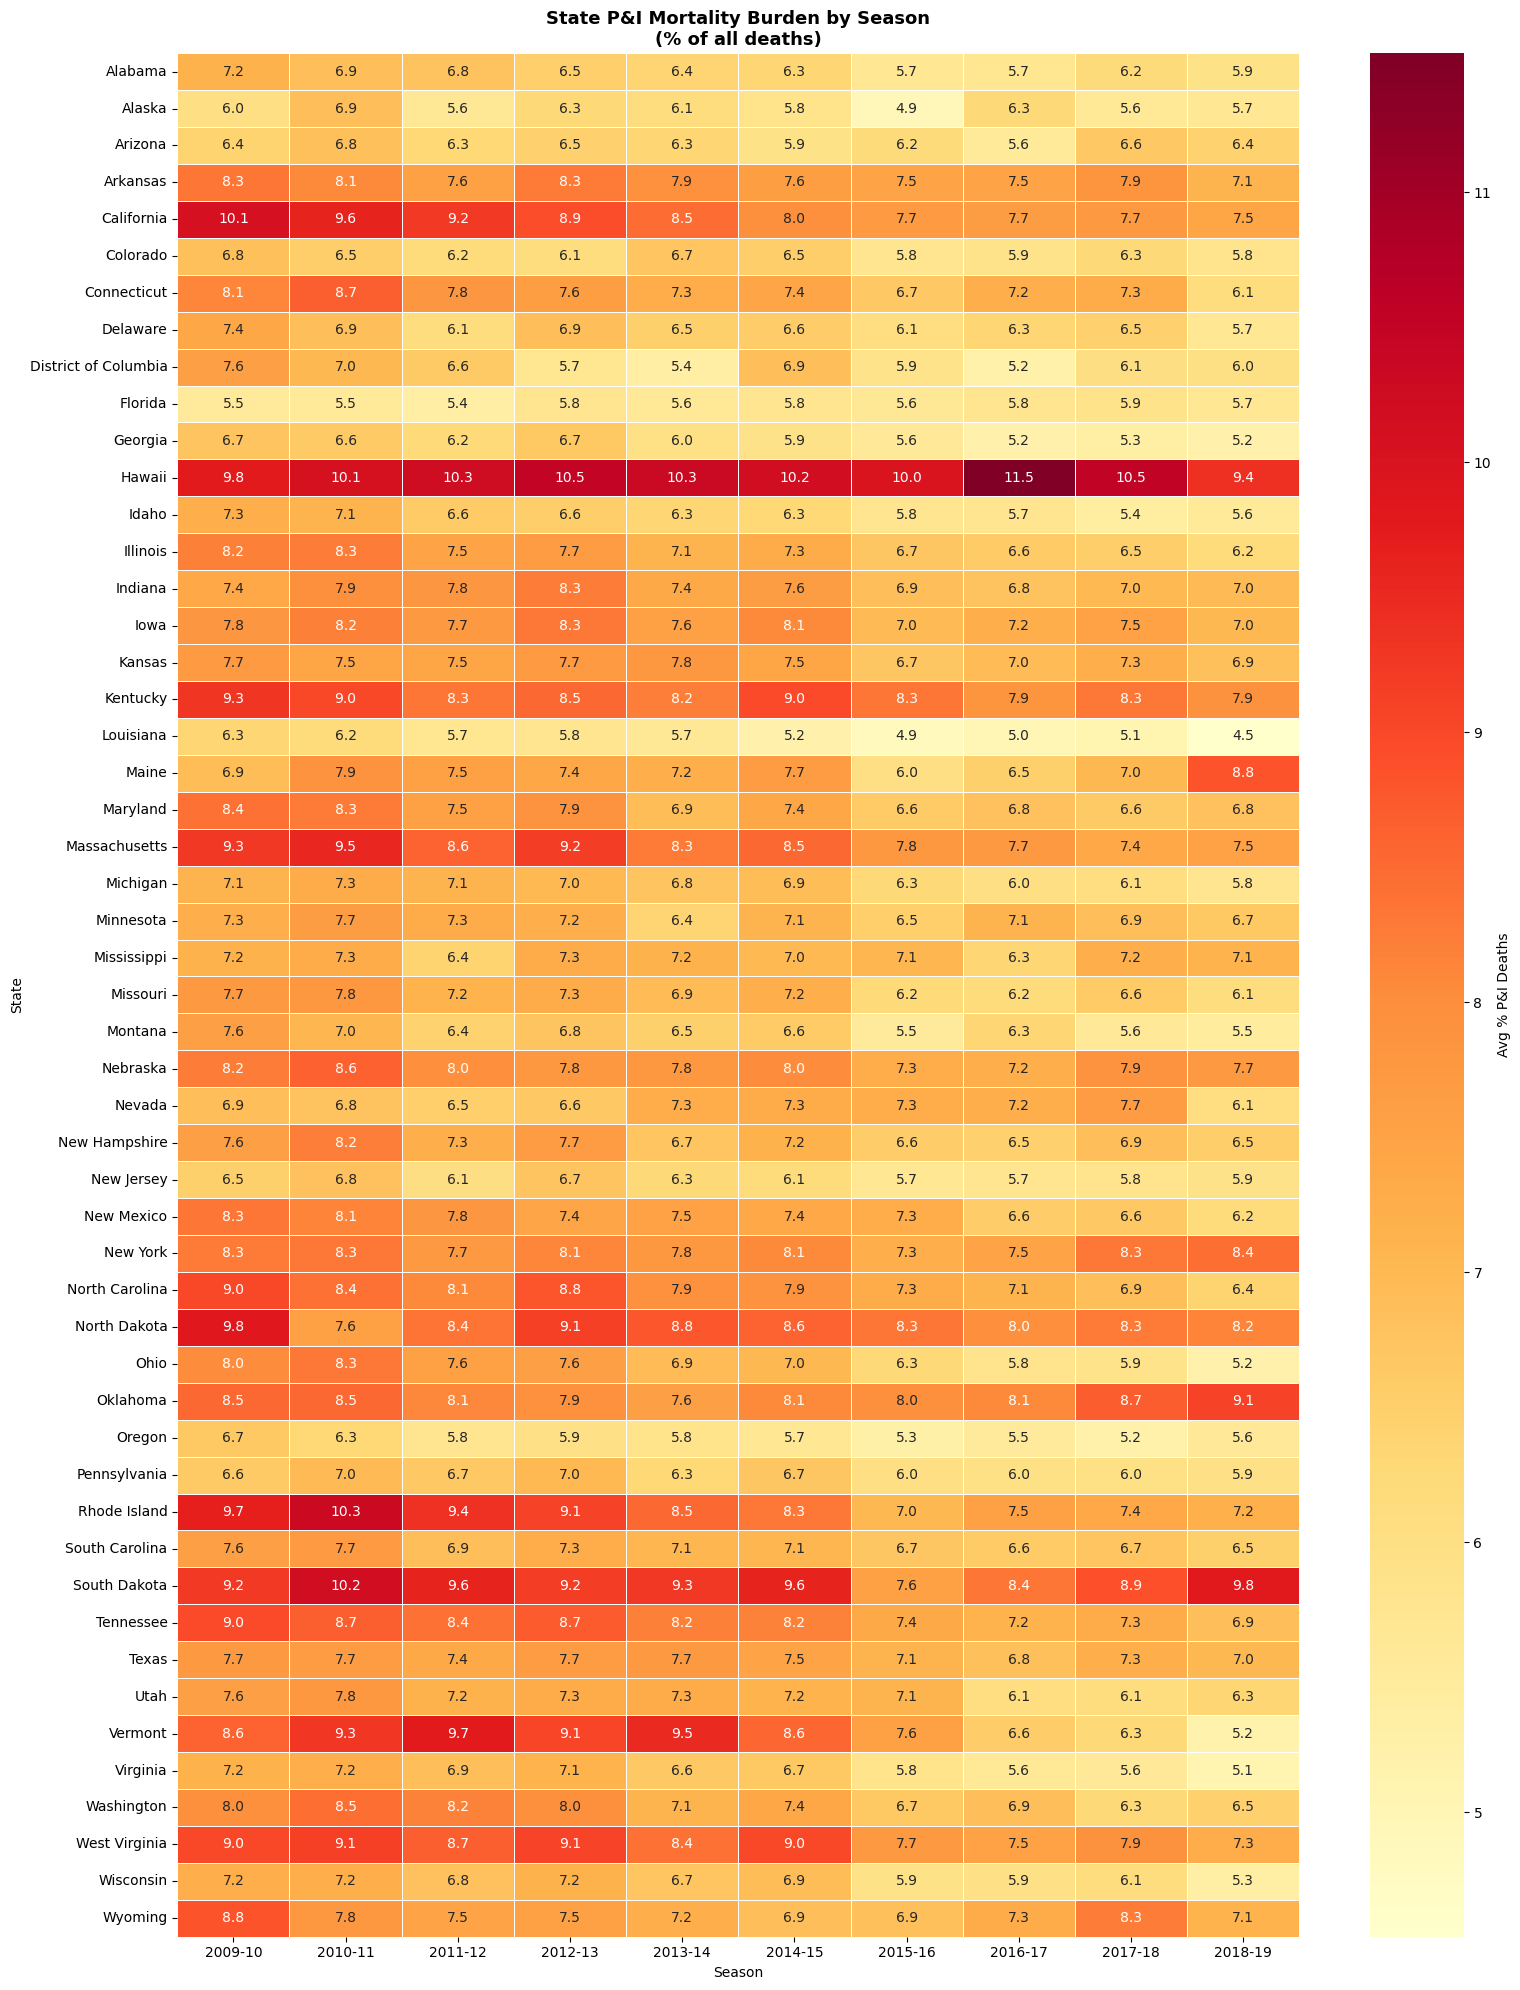

In [12]:
state_mort = query(f"""
select
    state,
    season,
    avg(pct_pi) as avg_pct_pi,
    sum(pi_deaths) as total_pi_deaths
from `{PROJECT}.{DATASET}.fct_state_mortality`
where state != ''
    and state not in ('Puetro Rico', 'New York City')
group by 1, 2
order by 1, 2
""")

pivot_state = state_mort.pivot(
    index='state',
    columns='season',
    values='avg_pct_pi'
).fillna(0)

fig, ax = plt.subplots(figsize=(16, 20))
sns.heatmap(pivot_state, annot=True, fmt='.1f',
           cmap='YlOrRd', ax=ax,
           cbar_kws={'label': 'Avg % P&I Deaths'},
           linewidths=0.5)
ax.set_title('State P&I Mortality Burden by Season\n(% of all deaths)',
            fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('State')

plt.tight_layout()
plt.savefig('state_mortality_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()